2. چرا باید عکس رو تبدیل کنیم؟

هر عکس یک جدول رنگیه (۳۲ در ۳۲ در ۳ رنگ = ۳۰۷۲ عدد).

کامپیوتر نمی‌فهمه "این گوشه‌ی عکس گوش گربه‌ست" یا "این چشم سگه"، فقط می‌فهمه عددها.

پس ما باید عکس رو به یک ردیف عدد (وکتور) تبدیل کنیم → بهش می‌گیم ویژگی‌ها (features).

3. مشکل: عددها خیلی زیادن!

هر عکس = ۳۰۷۲ عدد.

اگر ۲۰ هزار عکس داشته باشیم → یک جدول بزرگ با ۲۰ هزار ردیف و ۳۰۷۲ ستون داریم! 


این خیلی زیاده و آموزش کند می‌شه.
👉 راه‌حل: PCA → یک ترفند ریاضی برای خلاصه کردن اطلاعات.

مثلا می‌گیم فقط ۱۰۰ ویژگی مهم رو نگه دار، بقیه رو حذف کن.

شبیه اینه که شما به جای حفظ کردن همه‌ی کتاب، فقط خلاصه‌ی مهمش رو یاد می‌گیری.

-------------------------------------------------------------------

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 60s 0us/step
شکل داده‌ها: (10000, 3072) (2000, 3072)
شکل داده‌ها بعد از PCA: (10000, 100)
دقت روی داده تست: 67.10%


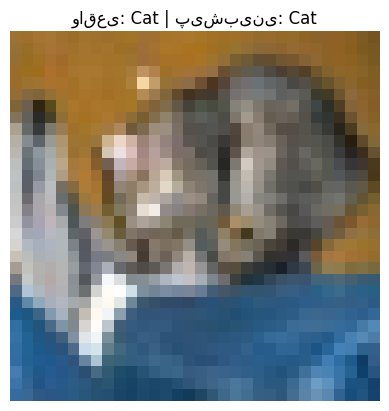

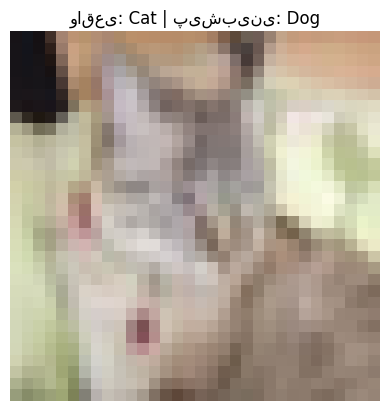

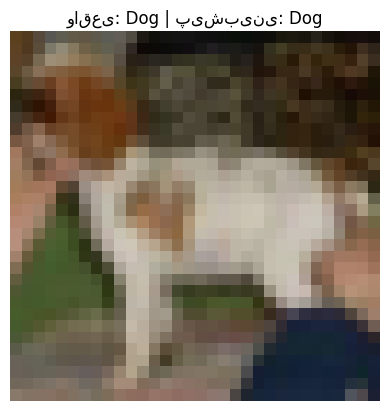

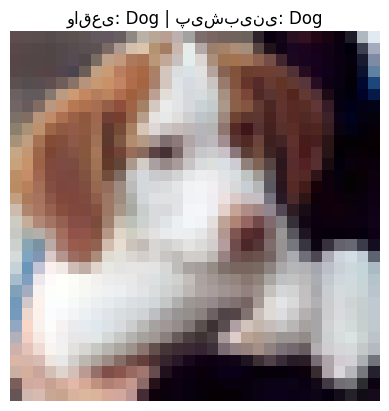

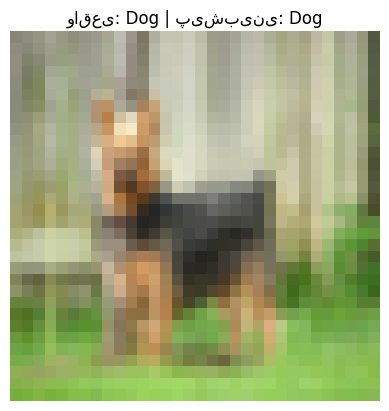

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from tensorflow.keras.datasets import cifar10


(X_train, y_train), (X_test, y_test) = cifar10.load_data()


y_train = y_train.flatten()
y_test = y_test.flatten()


train_filter = np.where((y_train == 3) | (y_train == 5))
test_filter = np.where((y_test == 3) | (y_test == 5))

X_train, y_train = X_train[train_filter], y_train[train_filter]
X_test, y_test = X_test[test_filter], y_test[test_filter]

# تغییر label ها: گربه=0 ، سگ=1
y_train = (y_train == 5).astype(int)
y_test = (y_test == 5).astype(int)

# نرمال‌سازی داده‌ها
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# تبدیل تصاویر به وکتور (32x32x3 → 3072)
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

print("شکل داده‌ها:", X_train.shape, X_test.shape)

# کاهش بعد با PCA 
pca = PCA(n_components=100)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print("شکل داده‌ها بعد از PCA:", X_train_pca.shape)


clf = SVC(kernel="rbf", gamma="scale")
clf.fit(X_train_pca, y_train)


y_pred = clf.predict(X_test_pca)
acc = accuracy_score(y_test, y_pred)
print(f"دقت روی داده تست: {acc*100:.2f}%")

for i in range(5):
    plt.imshow(X_test[i].reshape(32,32,3))
    plt.title(f"واقعی: {'Dog' if y_test[i]==1 else 'Cat'} | پیش‌بینی: {'Dog' if y_pred[i]==1 else 'Cat'}")
    plt.axis("off")
    plt.show()


In [2]:
# پروژه: دسته‌بندی گربه/سگ با SVM
# ---------------------------------
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from tensorflow.keras.datasets import cifar10

# 1. بارگذاری دیتاست CIFAR-10
#این مجموعه ۶۰هزار عکس کوچیک (۳۲ در ۳۲ پیکسل) از چیزای مختلف داره: هواپیما، ماشین، پرنده، اسب، گربه، سگ و ...
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

In [3]:

print(y_train.shape)   # (50000,)
print(y_test.shape) 

(50000, 1)
(10000, 1)


In [4]:
y_train = y_train.flatten()
y_test = y_test.flatten()

print(y_train.shape)   # (50000,)
print(y_test.shape) 

(50000,)
(10000,)


2️⃣ دستور np.where(condition)

تابع np.where در Numpy می‌گه:
«کجاها شرطی که دادی برقرار هست؟»
و خروجی‌اش ایندکس (اندیس) اون مکان‌هاست.

شرط (y_train == 3) | (y_train == 5)

(y_train == 3) → یه آرایه‌ی بولی می‌سازه، که برای هر عنصر True می‌شه اگه گربه باشه.

(y_train == 5) → برای سگ‌ها True.

علامت | یعنی OR → پس یا گربه، یا سگ.

In [ ]:
# انتخاب فقط گربه (3) و سگ (5)
train_filter = np.where((y_train == 3) | (y_train == 5))
test_filter = np.where((y_test == 3) | (y_test == 5))

خط‌های تغییر برچسب — (y_train == 5).astype(int) یعنی چه؟

(y_train == 5) یک آرایهٔ بولی (True/False) می‌سازه که True اونجا هست که تصویر سگ (label ۵) باشه. برای گربه (۳) مقدار False می‌شه.

.astype(int) تبدیل می‌کنه True -> 1 و False -> 0.

پس نتیجه: سگ‌ها 1، گربه‌ها 0. (یعنی دوتایی شدنِ برچسب برای «مسئلهٔ دودویی / binary classification»)

In [ ]:
X_train, y_train = X_train[train_filter], y_train[train_filter]
X_test, y_test = X_test[test_filter], y_test[test_filter]

# تغییر label ها: گربه=0 ، سگ=1
y_train = (y_train == 5).astype(int)
y_test = (y_test == 5).astype(int)

# نرمال‌سازی داده‌ها
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0